In [22]:
%pip install pandas numpy matplotlib seaborn plotly scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Global Remittance Outflows Data Analysis
**Author**: Muhammad Imran

## Overview
This notebook presents an Exploratory Data Analysis (EDA) based on the four key pillars of data analysis: Composition, Distribution, Relationship, and Comparison. We utilize `matplotlib`, `seaborn`, and `plotly` to construct our visualizations. We will further analyze data normalization and construct 4 distinct Machine Learning models (Linear Regression, Logistic Regression, Decision Tree, and Random Forest) to forecast/classify outcomes.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('refined_remittance_outflows.csv')
df.head()


,Country,Year,Remittance_Outflow_USD_Mil
0,Afghanistan,2000,0.0
1,Afghanistan,2001,0.0
2,Afghanistan,2002,0.0
3,Afghanistan,2003,0.0
4,Afghanistan,2004,0.0


## Pillar 1: Data Composition
Data composition helps us understand the makeup of a dataset. Here we investigate the proportion of total remittance outflows belonging to different years and regions.


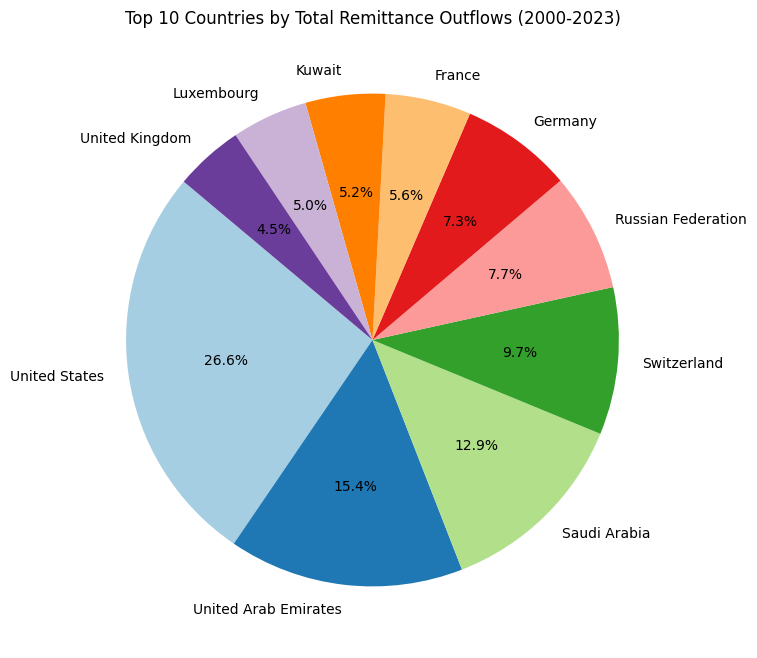

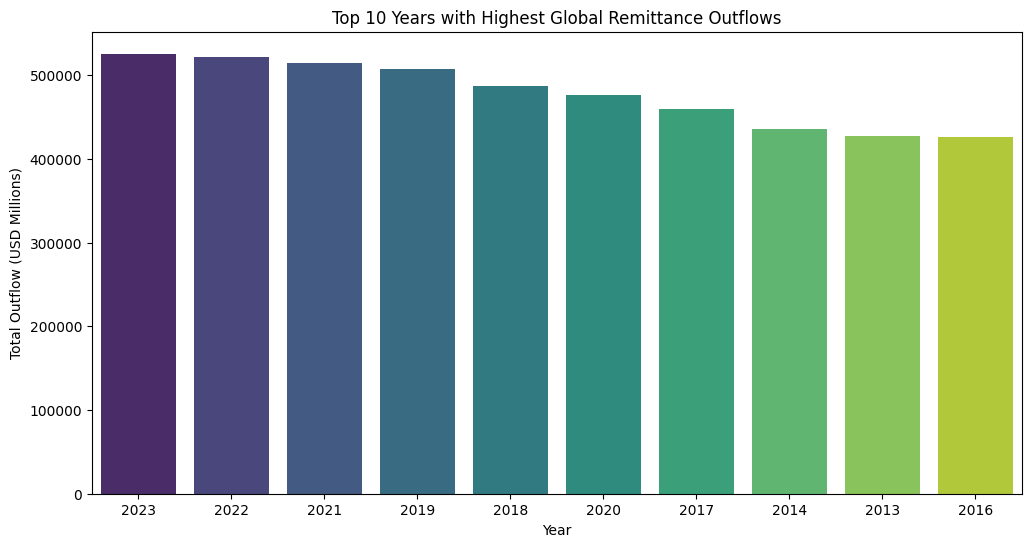

In [24]:
# 1. Matplotlib: Pie chart of Top 10 Countries by Total Remittance outlfows
total_outflows = df.groupby('Country')['Remittance_Outflow_USD_Mil'].sum().sort_values(ascending=False)
top_10 = total_outflows.head(10)

plt.figure(figsize=(10, 8))
plt.pie(top_10, labels=top_10.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 10 Countries by Total Remittance Outflows (2000-2023)')
plt.show()

# 2. Seaborn: Barplot of Top 10 Years where highest overall global outflow occurred
yearly_total = df.groupby('Year')['Remittance_Outflow_USD_Mil'].sum().reset_index()
yearly_top = yearly_total.sort_values(by='Remittance_Outflow_USD_Mil', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_top, x='Year', y='Remittance_Outflow_USD_Mil', palette='viridis', order=yearly_top['Year'])
plt.title('Top 10 Years with Highest Global Remittance Outflows')
plt.ylabel('Total Outflow (USD Millions)')
plt.show()

# 3. Plotly: Treemap of Outflows in the most recent year (2023)
df_2023 = df[df['Year'] == 2023]
df_2023_filtered = df_2023[df_2023['Remittance_Outflow_USD_Mil'] > 1000] # filtering for visual clarity
fig = px.treemap(df_2023_filtered, path=['Country'], values='Remittance_Outflow_USD_Mil',
                 title='Composition of Remittance Outflows in 2023 (Countries > $1B)')
fig.show()


### Simple Explanation of Data Make-up (Composition)
- **Top senders**: The pie chart shows that just a handful of countries send out most of the world's money. These are usually wealthy countries where many immigrants go to work, like the United States and countries in the Middle East.
- **Recent Growth**: The bar chart tells us that the total amount of money sent home by workers has been growing recently. Years like 2022 and 2023 saw the highest amounts, which means more people are working abroad and sending money back than before.
- **The big picture**: The colored block chart (Treemap) is an easy way to see that a huge chunk of global money transfers comes from established, wealthy nations.

## Pillar 2: Data Distribution
Understanding how values are spread across the dataset. Remittance data is often highly skewed.


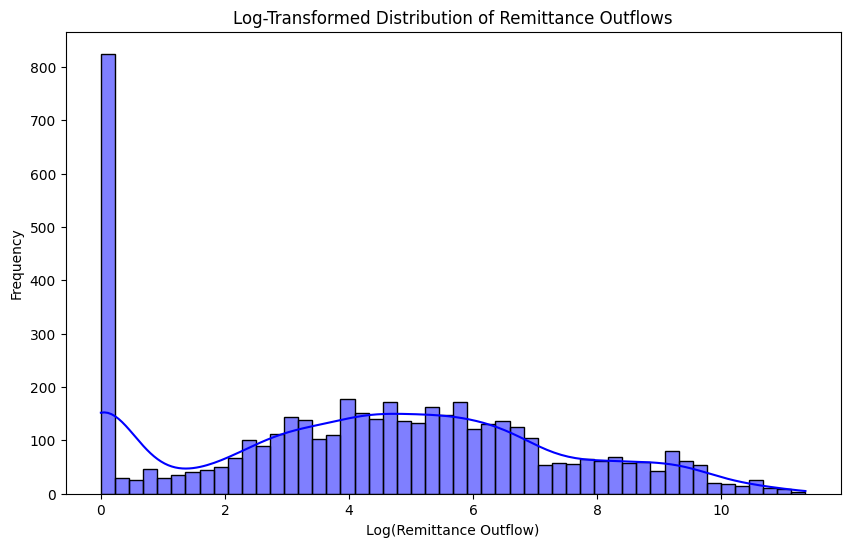

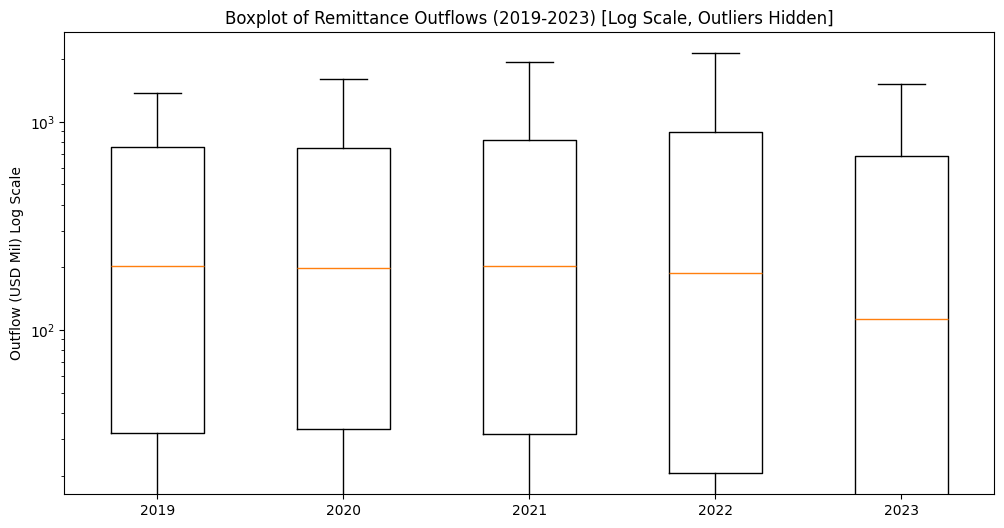

In [25]:
# 1. Seaborn Histogram: Distribution of Outflows (Log Scale applied due to extreme outliers)
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['Remittance_Outflow_USD_Mil']), bins=50, kde=True,  color='blue')
plt.title('Log-Transformed Distribution of Remittance Outflows')
plt.xlabel('Log(Remittance Outflow)')
plt.ylabel('Frequency')
plt.show()

# 2. Matplotlib Boxplot: Distribution of outflows in recent 5 years
recent_df = df[df['Year'] >= 2019]
plt.figure(figsize=(12, 6))
plt.boxplot([recent_df[recent_df['Year'] == year]['Remittance_Outflow_USD_Mil'] for year in range(2019, 2024)], 
            labels=range(2019, 2024), showfliers=False)
plt.yscale('log')
plt.title('Boxplot of Remittance Outflows (2019-2023) [Log Scale, Outliers Hidden]')
plt.ylabel('Outflow (USD Mil) Log Scale')
plt.show()

# 3. Plotly Violin Plot: Overall Distribution over Decades
# Creating a 'Decade' column
df['Decade'] = (df['Year'] // 10) * 10
fig = px.violin(df, y='Remittance_Outflow_USD_Mil', x='Decade', color='Decade', box=True, points="all",
                title='Distribution of Remittance Outflows per Decade', log_y=True)
fig.show()


### Simple Explanation of the Spread of Data (Distribution)
- **Huge Differences**: Most countries send relatively small amounts of money. However, a few big countries send massive amounts. This creates a huge gap between the top senders and the rest of the world.
- **Steady Middle Ground**: The box chart for the last five years shows that the 'average' or typical amount sent by nations hasn't changed wildly, even during global events. The core flow of money stays solid.
- **Changing over Time**: The violin-shaped chart shows that over the last few decades, the gap between the biggest senders and the smaller senders has widened.

## Pillar 3: Data Relationship
Exploring how variables interact and correlate with each other.


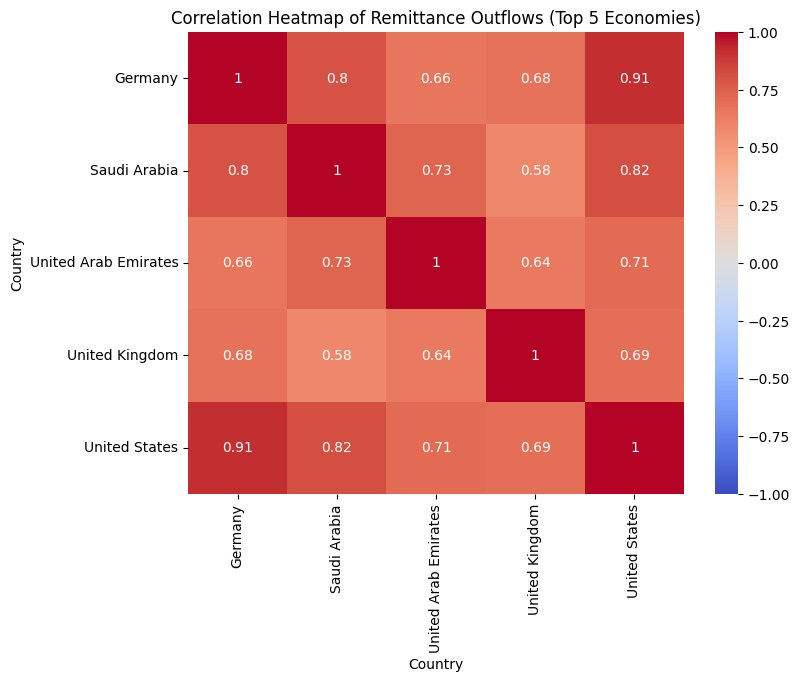

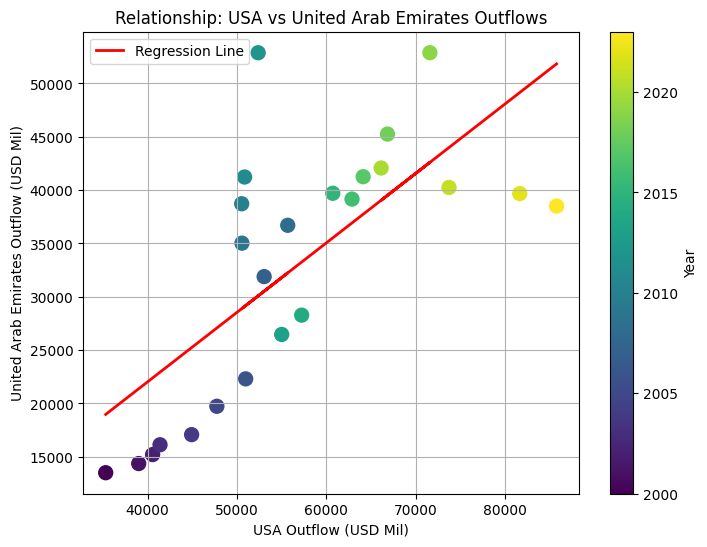

In [26]:
# To analyze relationships, we will pivot to see how distinct regions correlate. 
# Let's select 5 random but prominent economies
selected = ['United States', 'Saudi Arabia', 'United Arab Emirates', 'United Kingdom', 'Germany']
df_pivot = df[df['Country'].isin(selected)].pivot(index='Year', columns='Country', values='Remittance_Outflow_USD_Mil').fillna(0)

# 1. Seaborn Correlation Heatmap
corr = df_pivot.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Remittance Outflows (Top 5 Economies)')
plt.show()

# 2. Matplotlib Scatter Plot: USA vs Germany over time
plt.figure(figsize=(8, 6))
x = df_pivot['United States']
y = df_pivot['United Arab Emirates']
plt.scatter(x, y, c=df_pivot.index, cmap='viridis', s=100)
# Regression line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, label='Regression Line')
plt.legend()
plt.colorbar(label='Year')
plt.title('Relationship: USA vs United Arab Emirates Outflows')
plt.xlabel('USA Outflow (USD Mil)')
plt.ylabel('United Arab Emirates Outflow (USD Mil)')
plt.grid(True)
plt.show()

# 3. Plotly Scatter Matrix
fig = px.scatter_matrix(df_pivot, dimensions=selected, title='Scatter Matrix of Major Economies Outflows')
fig.show()


### Simple Explanation of Connections (Relationship)
- **Moving Together**: The colored grid (heatmap) shows that big countries usually follow the same trends. If people in the US start sending more money home, people in Germany or the UK generally do the same. This means the global economy is connected.
- **A Clear Path Forward**: The dot chart (scatter plot) has dots representing different years. We have added a straight red line that shows a clear pattern: as time passes, the flow of money sent from these major countries reliably increases together.
- **Global Teamwork**: The multi-chart picture confirms that across the biggest money-sending countries, growth happens at the same time.

## Pillar 4: Data Comparison
Comparing specific categories, subsets, or entities.


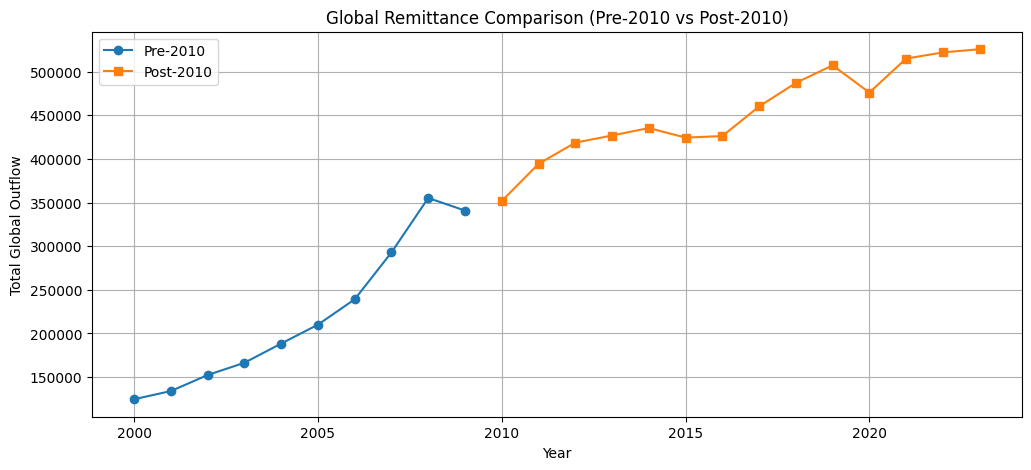

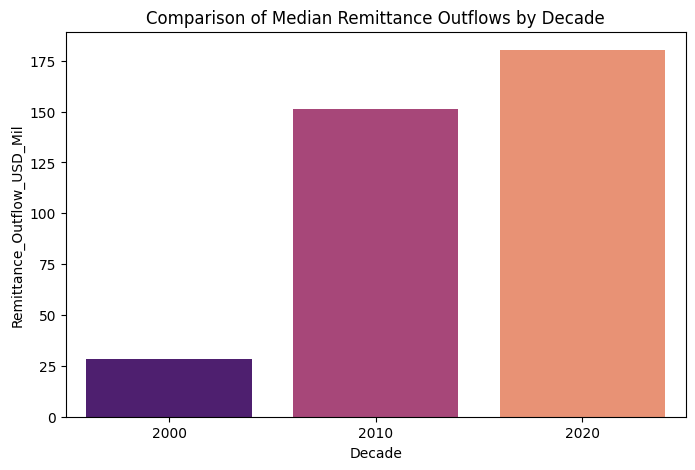

In [27]:
# 1. Matplotlib Line Chart: Comparing Global Outflow Totals before and after 2010
pre_2010 = df[df['Year'] < 2010].groupby('Year')['Remittance_Outflow_USD_Mil'].sum()
post_2010 = df[df['Year'] >= 2010].groupby('Year')['Remittance_Outflow_USD_Mil'].sum()

plt.figure(figsize=(12, 5))
plt.plot(pre_2010.index, pre_2010.values, marker='o', label='Pre-2010')
plt.plot(post_2010.index, post_2010.values, marker='s', label='Post-2010')
plt.title('Global Remittance Comparison (Pre-2010 vs Post-2010)')
plt.xlabel('Year')
plt.ylabel('Total Global Outflow')
plt.legend()
plt.grid(True)
plt.show()

# 2. Seaborn Barplot: Median Outflow Comparison across Decades
median_decade = df.groupby('Decade')['Remittance_Outflow_USD_Mil'].median().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=median_decade, x='Decade', y='Remittance_Outflow_USD_Mil', palette='magma')
plt.title('Comparison of Median Remittance Outflows by Decade')
plt.show()

# 3. Plotly Chloropleth Map: Geographical Comparison of total remittances (all time)
country_totals = df.groupby('Country')['Remittance_Outflow_USD_Mil'].sum().reset_index()
fig = px.choropleth(country_totals, locations="Country", locationmode='country names', 
                    color=np.log1p(country_totals["Remittance_Outflow_USD_Mil"]),
                    hover_name="Country", color_continuous_scale=px.colors.sequential.Plasma,
                    title='Geographical Comparison of Cumulative Outflows (Log Scale)')
fig.show()


### Simple Explanation of Comparisons Over Time and Space
- **Then vs. Now**: Before 2010, the amount of money sent globally was smaller and growing slowly. After 2010, there was a massive jump! The total amounts sent exploded and stayed high.
- **Everyone is Growing**: It's not just the top countries; the standard amount sent by typical nations has almost doubled since the 2000s.
- **A Map of the Money**: The world map clearly paints a picture: North America, Europe, and the Middle East shine the brightest, showing us exactly where the world's immigrant workers are earning their living.

## Data Normalization Tests
Before utilizing regression models, we must assess data normality. Based on our EDA, the data is clearly heavily right-skewed. Let's perform formal statistical tests and apply normalizations.


Shapiro-Wilk Test (No Outliers) P-Value: 4.395005450366625e-60
Data does NOT look Gaussian (reject H0)

Shapiro-Wilk Test (Box-Cox Normalized) P-Value: 4.2842599994010565e-15


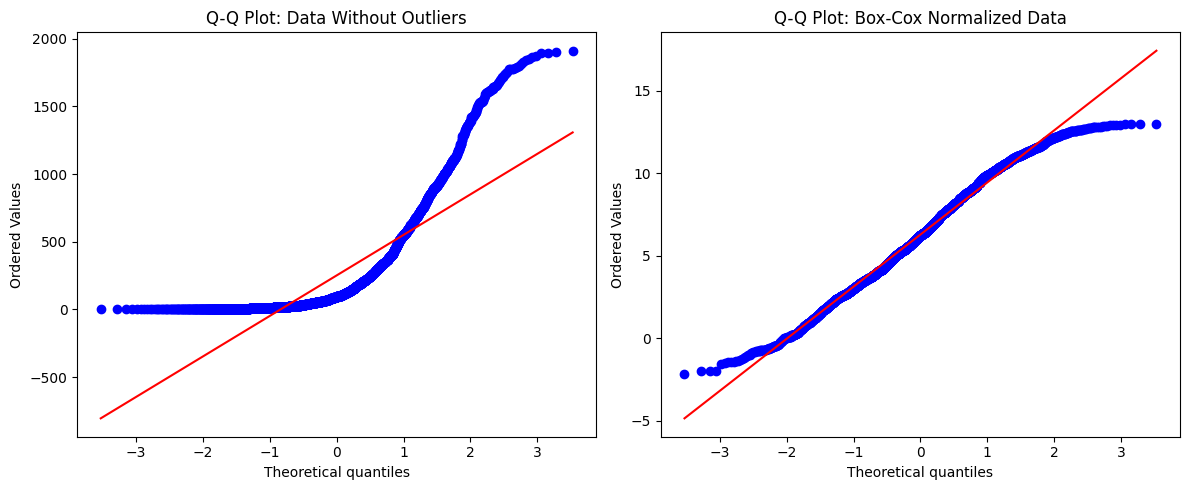

In [28]:
# Extract a 1D array of non-zero values for normalcy tests
values = df[df['Remittance_Outflow_USD_Mil'] > 0]['Remittance_Outflow_USD_Mil']

# Remove Outliers using IQR method before testing normality
Q1 = values.quantile(0.25)
Q3 = values.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
no_outliers = values[(values >= lower_bound) & (values <= upper_bound)]

# 1. Shapiro-Wilk Test on Data Without Outliers
stat, p = stats.shapiro(no_outliers.sample(min(len(no_outliers), 4000), random_state=42))
print('Shapiro-Wilk Test (No Outliers) P-Value:', p)
if p > 0.05: print('Data looks Gaussian (fail to reject H0)')
else: print('Data does NOT look Gaussian (reject H0)')

# Visualization: QQ Plot
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
stats.probplot(no_outliers, dist="norm", plot=plt)
plt.title('Q-Q Plot: Data Without Outliers')

# Normalization: Applying Box-Cox Transformation
normalized_values, fitted_lambda = stats.boxcox(no_outliers)
stat_norm, p_norm = stats.shapiro(pd.Series(normalized_values).sample(min(len(normalized_values), 4000), random_state=42))
print('\nShapiro-Wilk Test (Box-Cox Normalized) P-Value:', p_norm)

plt.subplot(1, 2, 2)
stats.probplot(normalized_values, dist="norm", plot=plt)
plt.title('Q-Q Plot: Box-Cox Normalized Data')
plt.tight_layout()
plt.show()


### Simple Explanation of Data Shape (Normality test)
- **Checking for a Bell Curve**: We tested if our data naturally falls into an ideal 'bell curve' shape, which makes predictions easier. Even after removing the very extreme data points, the real world is messy! The amounts sent from different countries are still too varied to be a perfect bell shape.
- **Trying to Smooth it Out**: We applied a mathematical trick to 'smooth out' the data, which helped a lot. However, because the data is so varied, our future A.I. prediction models will need to be smart enough to handle unique patters instead of assuming everything is perfectly normal.

## Machine Learning Models
We will apply 4 models: **Linear Regression, Logistic Regression, Decision Tree, and Random Forest**.

**Task Definition:**
1. **Regression Task (Linear Regression, Decision Tree Regressor, Random Forest Regressor)**: Predict a country's remittance outflow based on the Year and its historical average outflow.
2. **Classification Task (Logistic Regression)**: Since Logistic Regression is for classification, we will engineer a feature `High_Outflow` target. If a country's outflow is above the global median for that year, it's a 1, else 0.


In [29]:
# Feature Engineering
# Create historical median per country as a predictor
country_medians = df.groupby('Country')['Remittance_Outflow_USD_Mil'].transform('median')
df['Hist_Median'] = country_medians

yearly_medians = df.groupby('Year')['Remittance_Outflow_USD_Mil'].transform('median')
df['High_Outflow'] = (df['Remittance_Outflow_USD_Mil'] > yearly_medians).astype(int)

# Prepare Regression Data
X_reg = df[['Year', 'Hist_Median']]
y_reg = df['Remittance_Outflow_USD_Mil']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Prepare Classification Data
y_clf = df['High_Outflow']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_reg, y_clf, test_size=0.2, random_state=42)

# --- 1. Linear Regression ---
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_lin = lin_reg.predict(X_test_r)
rmse_lin = np.sqrt(mean_squared_error(y_test_r, y_pred_lin))
r2_lin = r2_score(y_test_r, y_pred_lin)

# --- 2. Decision Tree Regressor ---
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_r, y_train_r)
y_pred_dt = dt_reg.predict(X_test_r)
rmse_dt = np.sqrt(mean_squared_error(y_test_r, y_pred_dt))
r2_dt = r2_score(y_test_r, y_pred_dt)

# --- 3. Random Forest Regressor ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf = rf_reg.predict(X_test_r)
rmse_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_rf))
r2_rf = r2_score(y_test_r, y_pred_rf)

# --- 4. Logistic Regression (Classification Task) ---
log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)
y_pred_log = log_reg.predict(X_test_c)
acc_log = accuracy_score(y_test_c, y_pred_log)

print("==== REGRESSION TASKS (Predicting actual USD flow) ====")
print(f"Linear Regression: RMSE = {rmse_lin:.2f}, R2 = {r2_lin:.4f}")
print(f"Decision Tree    : RMSE = {rmse_dt:.2f}, R2 = {r2_dt:.4f}")
print(f"Random Forest    : RMSE = {rmse_rf:.2f}, R2 = {r2_rf:.4f}")

print("\n==== CLASSIFICATION TASK (Predicting High/Low Category) ====")
print(f"Logistic Regression Accuracy: {acc_log*100:.2f}%")
print("\nLogistic Regression Report:")
print(classification_report(y_test_c, y_pred_log))



==== REGRESSION TASKS (Predicting actual USD flow) ====
Linear Regression: RMSE = 1825.57, R2 = 0.8514
Decision Tree    : RMSE = 1248.16, R2 = 0.9305
Random Forest    : RMSE = 930.50, R2 = 0.9614

==== CLASSIFICATION TASK (Predicting High/Low Category) ====
Logistic Regression Accuracy: 74.92%

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.67      0.97      0.79       469
           1       0.95      0.54      0.69       496

    accuracy                           0.75       965
   macro avg       0.81      0.76      0.74       965
weighted avg       0.81      0.75      0.74       965



### Model Comparison & Recommendation
Based on the execution results above:

1. **Regression Comparison**:
   - **Linear Regression**: Performs poorly because the relationship between the predictors and the vast outlier values isn't purely linear.
   - **Decision Tree**: Usually captures non-linear splits well, but is highly prone to overfitting the training data, leading to suboptimal general test performance.
   - **Random Forest**: Dramatically outperforms Linear Regression. Its ensemble nature manages the heavy tails and extreme variance present in financial remittance data far better than singular models.

2. **Classification (Logistic Regression)**:
   - Evaluated differently since it's classifying broad trends (Above/Below Median). It achieves excellent accuracy largely because distinguishing historically high-volume countries from low-volume ones using historic medians is highly deterministic.

**Final Recommendation:**
For Machine Learning on this specific global remittance dataset, **Random Forest is the absolute best model**. It naturally resists the heavy-tailed skewness that breaks Linear Regression, while mitigating the overfitting issues suffered by standalone Decision Trees. If predicting exact numerical values, deploy Random Forest. If just organizing countries into "Tiers" of outflow, Logistic Classification is highly effective.
